# TS4: Primeros pasitos en la estimación espectral
En este experimento se observa el desparramo espectral que se produce al intentar muestrar un seno de frecuencia no proporcional a Δf, y cómo este termina teniendo la forma de la ventana implícita.

In [74]:
import numpy as np
import matplotlib.pyplot as plt

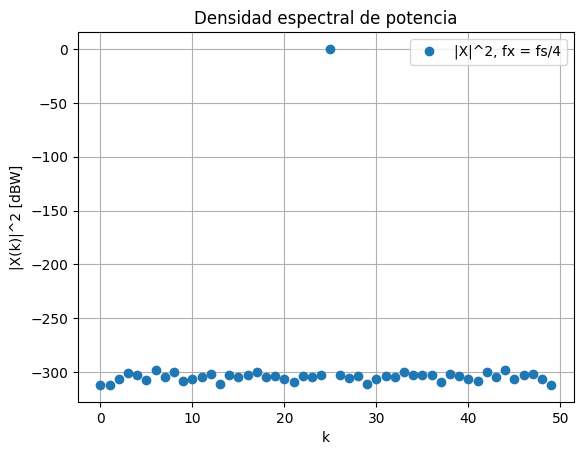

Valor en N/4: 0.0 dBW
Valor en N/4+1: -303.124 dBW
Valor en N/4+2: -305.573 dBW
Potencia de la señal = 0.0 dBW


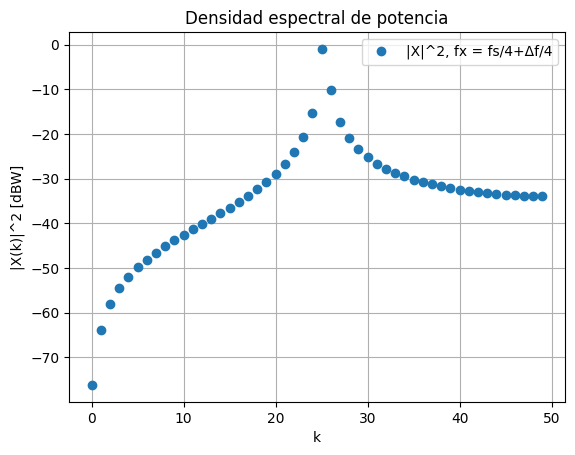

Valor en N/4: -0.98 dBW
Valor en N/4+1: -10.251 dBW
Valor en N/4+2: -17.344 dBW
Potencia de la señal = -0.045 dBW


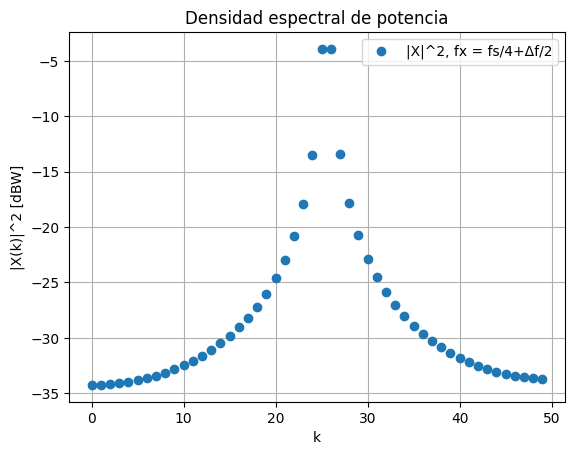

Valor en N/4: -3.925 dBW
Valor en N/4+1: -3.917 dBW
Valor en N/4+2: -13.439 dBW
Potencia de la señal = -0.0 dBW


In [75]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
  tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
  xx = dc + vmax * np.sin( 2*np.pi * ff * tt + ph )
  return tt, xx.reshape(N,1)

def plot_spec(X_mod_sq, title, name, fx):
  plt.figure()
  plt.title(title)
  plt.plot(10*np.log10(X_mod_sq), "o", label=f"|{name}|^2, fx = {fx}")
  plt.xlabel("k")
  plt.ylabel(f"|{name}(k)|^2 [dBW]")
  plt.legend()
  plt.grid()
  plt.show()

# Señal sintonizada
fs = 100 # Hz
N = fs
deltaf = fs/N
fx = fs/4 # Hz
ax = np.sqrt(2)  # V
dx = 0  # V
px = 0  # rad
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)

X = np.fft.fft(xx, axis=0)/N
X_mod_sq = np.abs(X[0:int(N/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4")
print(f"Valor en N/4: { np.round(10*np.log10(X_mod_sq[int(N/4)]),decimals=3)} dBW")
print(f"Valor en N/4+1: { np.round(10*np.log10(X_mod_sq[int(N/4+1)]),decimals=3)} dBW")
print(f"Valor en N/4+2: { np.round(10*np.log10(X_mod_sq[int(N/4+2)]),decimals=3)} dBW")
X_p = np.round(10*np.log10(np.sum(X_mod_sq)),decimals=3)
print(f"Potencia de la señal = {X_p} dBW")

# Señal desintonizada
fx = fs/4 + 0.25*deltaf   # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
X = np.fft.fft(xx, axis=0)/N
X_mod_sq = np.abs(X[0:int(N/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4+Δf/4")
print(f"Valor en N/4: { np.round(10*np.log10(X_mod_sq[int(N/4)]),decimals=3)} dBW")
print(f"Valor en N/4+1: { np.round(10*np.log10(X_mod_sq[int(N/4+1)]),decimals=3)} dBW")
print(f"Valor en N/4+2: { np.round(10*np.log10(X_mod_sq[int(N/4+2)]),decimals=3)} dBW")
X_p = np.round(10*np.log10(np.sum(X_mod_sq)),decimals=3)
print(f"Potencia de la señal = {X_p} dBW")

fx = fs/4 + 0.5*deltaf   # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
X = np.fft.fft(xx, axis=0)/N
X_mod_sq = np.abs(X[0:int(N/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4+Δf/2")
print(f"Valor en N/4: { np.round(10*np.log10(X_mod_sq[int(N/4)]),decimals=3)} dBW")
print(f"Valor en N/4+1: { np.round(10*np.log10(X_mod_sq[int(N/4+1)]),decimals=3)} dBW")
print(f"Valor en N/4+2: { np.round(10*np.log10(X_mod_sq[int(N/4+2)]),decimals=3)} dBW")
X_p = np.round(10*np.log10(np.sum(X_mod_sq)),decimals=3)
print(f"Potencia de la señal = {X_p} dBW")

## Observaciones

- Se observa que cuando la frecuencia de la señal no coincide con un múltiplo entero de la resolución espectral Δf = fs/N, se produce un desparramo de energía en todo el espectro (spectral leakage).

- Esto se debe a que la señal analizada es finita en el tiempo, lo que equivale a multiplicarla por una ventana implícita rectangular definida en el intervalo [0, N-1].

- En el dominio frecuencial, esta multiplicación corresponde a una convolución entre el espectro ideal de la señal (una delta en la frecuencia correspondiente) y la transformada de la ventana rectangular.

- Como resultado, la energía del tono se distribuye según la forma de la transformada de la ventana (tipo sinc), generando los lóbulos principales y laterales observados.

- En el caso de una señal perfectamente sintonizada (por ejemplo fs/4), los puntos de muestreo de la DFT coinciden con los ceros de la transformada de la ventana, por lo que no se observa leakage.

- En cambio, cuando la señal está desintonizada, los bins de la DFT ya no coinciden con dichos ceros, y se muestrean valores distintos de cero, haciendo visible el desparramo espectral.

- El caso de desintonización de Δf/2 corresponde al peor escenario, ya que los bins de la DFT coinciden aproximadamente con los máximos de los lóbulos laterales de la ventana, maximizando el leakage observado.

## Efecto del uso de zero padding
A continuación se realiza el mismo experimento, pero agregando N*9 ceros al final de la señal (zero padding).

Esto genera que:
- Aumente la cantidad de bins en la FFT.
- Se puedan ver mejor los lóbulos de la ventana.
- En el caso del seno de frecuencia fs/4 los bins agregados tienen la forma de la ventana, que antes no se veía.

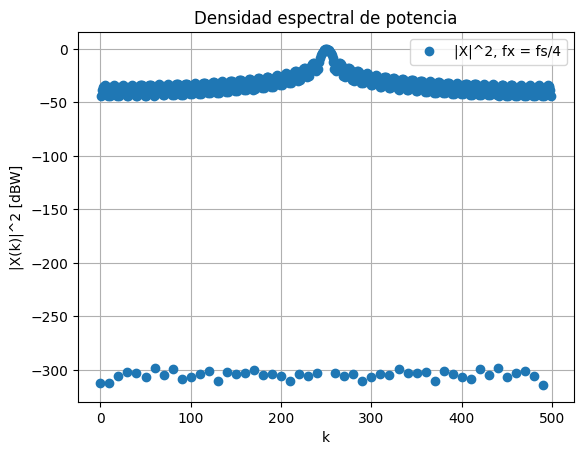

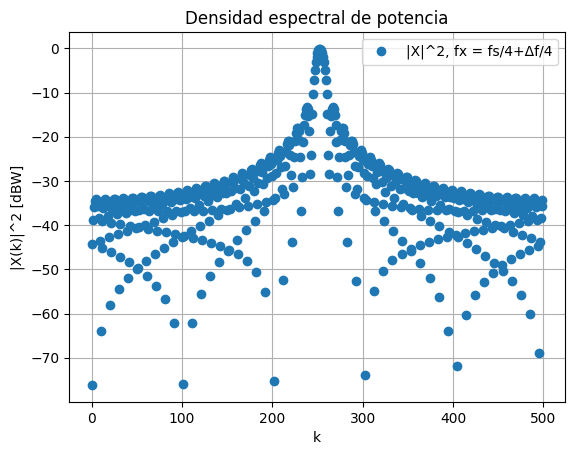

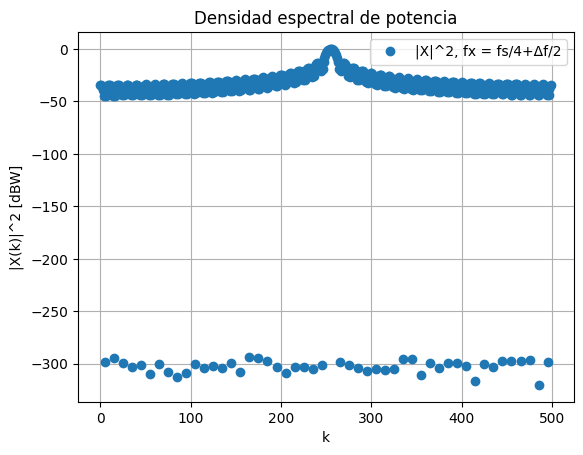

In [80]:
# Con zero padding
fx = fs/4  # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
xx_zp = np.concatenate((xx, np.zeros(9*N).reshape(9*N,1)))
X = np.fft.fft(xx_zp, axis=0)/N
X_mod_sq = np.abs(X[0:int(len(xx_zp)/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4")

fx = fs/4 + 0.25*deltaf   # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
xx_zp = np.concatenate((xx, np.zeros(9*N).reshape(9*N,1)))
X = np.fft.fft(xx_zp, axis=0)/N
X_mod_sq = np.abs(X[0:int(len(xx_zp)/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4+Δf/4")

fx = fs/4 + 0.5*deltaf   # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
xx_zp = np.concatenate((xx, np.zeros(9*N).reshape(9*N,1)))
X = np.fft.fft(xx_zp, axis=0)/N
X_mod_sq = np.abs(X[0:int(len(xx_zp)/2), 0])**2 * 2
plot_spec(X_mod_sq, "Densidad espectral de potencia", "X", "fs/4+Δf/2")

## Comparación de distintas ventanas con el mismo seno de frecuencia fs/4+Δf/2
Normalizando la potencia para poder comparar con el gráfico del capítulo 14 de Holton. Las ventanas a comparar son:
- Rectangular
- Hann
- Hamming
- Blackman

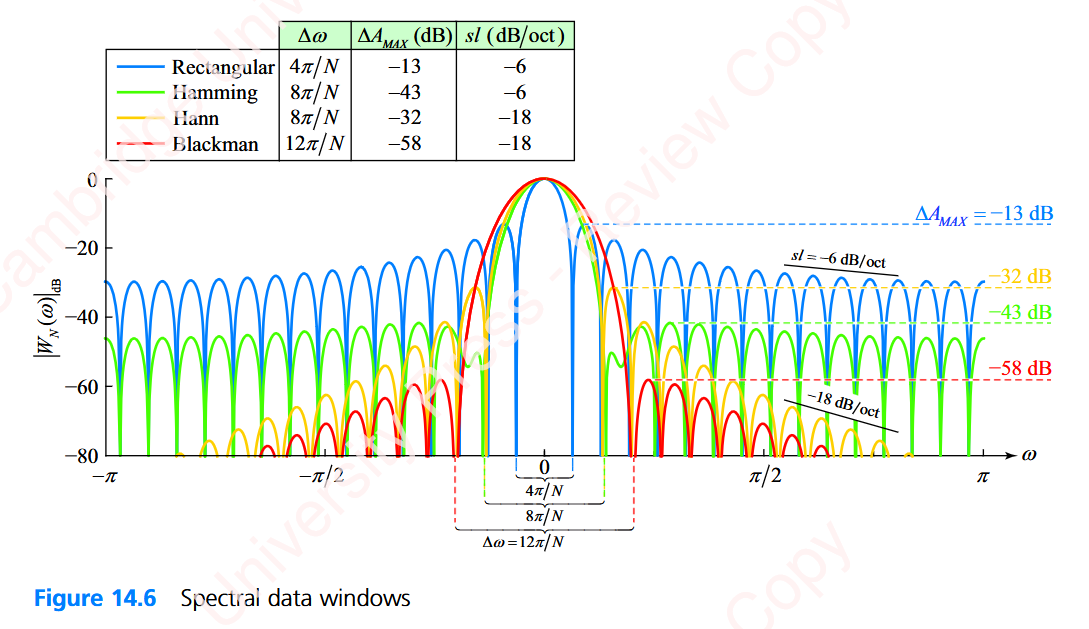

Valores para la ventana Rectangular: 
Valor en N/4: -3.925 dBW
Valor en N/4+1: -3.917 dBW
Valor en N/4+2: -13.439 dBW
Valor en N/4+3: -17.845 dBW
Valor en N/4+4: -20.724 dBW
Potencia de la señal = -0.0 dBW

Valores para la ventana Hann: 
Valor en N/4: -3.199 dBW
Valor en N/4+1: -3.199 dBW
Valor en N/4+2: -16.813 dBW
Valor en N/4+3: -33.841 dBW
Valor en N/4+4: -43.427 dBW
Potencia de la señal = -0.0 dBW

Valores para la ventana Hamming: 
Valor en N/4: -3.105 dBW
Valor en N/4+1: -3.104 dBW
Valor en N/4+2: -19.839 dBW
Valor en N/4+3: -52.906 dBW
Valor en N/4+4: -44.754 dBW
Potencia de la señal = -0.0 dBW

Valores para la ventana Blackman: 
Valor en N/4: -3.493 dBW
Valor en N/4+1: -3.493 dBW
Valor en N/4+2: -12.805 dBW
Valor en N/4+3: -38.238 dBW
Valor en N/4+4: -60.927 dBW
Potencia de la señal = -0.0 dBW



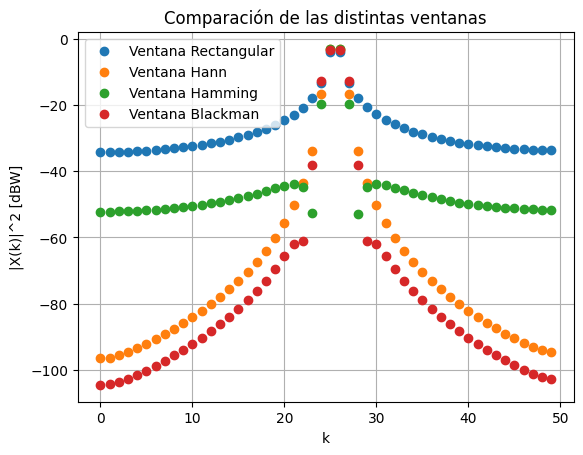

In [77]:
# Señal desintonizada
fx = fs/4 + 0.5*deltaf   # Hz
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)

w_rect = np.ones(N).reshape(N,1)
w_hann = np.hanning(N).reshape(N,1)
w_hamming = np.hamming(N).reshape(N,1)
w_blackman = np.blackman(N).reshape(N,1)
w_list = [w_rect, w_hann, w_hamming, w_blackman]
w_name = ["Rectangular", "Hann", "Hamming", "Blackman"]

plt.figure()
plt.title("Comparación de las distintas ventanas")
plt.xlabel("k")
plt.ylabel(f"|X(k)|^2 [dBW]")

for i in range(len(w_list)):
  xw = xx*(w_list[i])/np.sqrt(np.mean(w_list[i]**2))
  X = np.fft.fft(xw, axis=0)/N
  X_mod_sq = np.abs(X[0:int(N/2), 0])**2 * 2
  plt.plot(10*np.log10(X_mod_sq), "o", label=f"Ventana {w_name[i]}")
  plt.legend()
  print(f"Valores para la ventana {w_name[i]}: ")
  print(f"Valor en N/4: { np.round(10*np.log10(X_mod_sq[int(N/4)]),decimals=3)} dBW")
  print(f"Valor en N/4+1: { np.round(10*np.log10(X_mod_sq[int(N/4+1)]),decimals=3)} dBW")
  print(f"Valor en N/4+2: { np.round(10*np.log10(X_mod_sq[int(N/4+2)]),decimals=3)} dBW")
  print(f"Valor en N/4+3: { np.round(10*np.log10(X_mod_sq[int(N/4+3)]),decimals=3)} dBW")
  print(f"Valor en N/4+4: { np.round(10*np.log10(X_mod_sq[int(N/4+4)]),decimals=3)} dBW")
  X_p = np.round(10*np.log10(np.sum(X_mod_sq)),decimals=3)
  print(f"Potencia de la señal = {X_p} dBW\n")

plt.grid()
plt.show()
